Testing patient: 1.3.6.1.4.1.9328.50.4.0684
Original Shape (Raw H5): (401, 512, 512)
Transposed Shape (Output): (512, 512, 401)


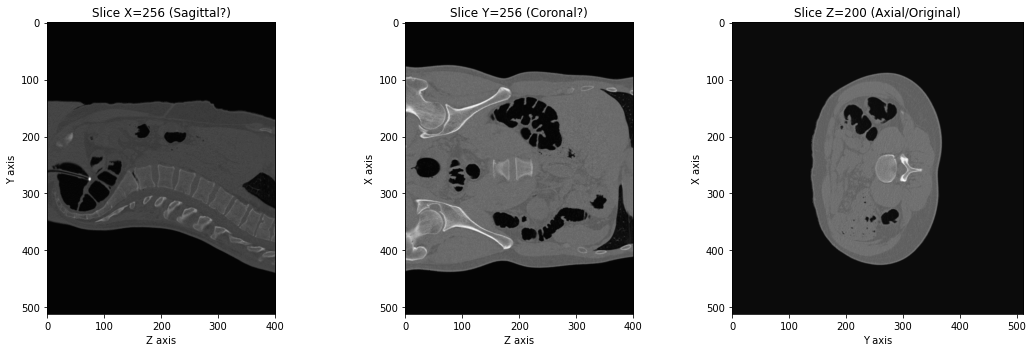

------------------------------
Final Volume Shape: (512, 512, 401)
请观察上图：
1. Slice Z (最右边) 是否是一张正常的、不变形的 CT 横截面图？
   如果是，说明 X, Y 轴正确。
2. Slice X 和 Slice Y 是否显示了脊柱的侧面和正面？
   如果是，说明 Z 轴被正确放到了第三个维度。
3. 你的 Z 轴长度是 401，这是否符合该病人的预期层数？


In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1. 模拟 dataset.py 里的 load_ct 函数逻辑
def load_ct_test(name, val_root):
    path = os.path.join(val_root, name, 'ct_xray_data.h5')
    
    if not os.path.exists(path):
        print(f"File not found: {path}")
        return None

    with h5py.File(path, 'r') as f:
        # 原始读取 (通常是 Z, Y, X 或 Z, H, W)
        image = f['ct'][:] 
    
    print(f"Original Shape (Raw H5): {image.shape}")
    
    image = image.astype(np.float32)
    
    # 模拟归一化 (简单做，只看形状)
    # image = (image - min) / (max - min)
    
    # 【关键步骤】转置 (Transpose)
    # 您的 dataset.py 里是: image = np.transpose(image, (2, 1, 0))
    # 假设原始是 (Z, Y, X)，转置后变成 (X, Y, Z)
    image_transposed = np.transpose(image, (2, 1, 0))
    
    print(f"Transposed Shape (Output): {image_transposed.shape}")
    
    return image_transposed

# 2. 设置路径 (请修改为您服务器的真实路径)
val_root = "/root/aicp-data/val_data/"

# 获取一个真实的病例名字
# 简单列出目录下的第一个文件夹名
subdirs = [d for d in os.listdir(val_root) if os.path.isdir(os.path.join(val_root, d))]
if not subdirs:
    print("Error: No subdirectories found in val_root.")
else:
    test_name = subdirs[0] # 取第一个测试
    print(f"Testing patient: {test_name}")
    
    # 3. 加载数据
    vol = load_ct_test(test_name, val_root)
    
    if vol is not None:
        # 4. 可视化检查 (重点！)
        # 如果维度是 (X, Y, Z) = (512, 512, 450)
        # 这里的 X, Y, Z 应该分别对应: 矢状面(Sagittal), 冠状面(Coronal), 横断面(Axial)
        
        x_mid = vol.shape[0] // 2
        y_mid = vol.shape[1] // 2
        z_mid = vol.shape[2] // 2
        
        plt.figure(figsize=(15, 5))
        
        # 切片 1: 固定 X轴 (应该看到 Y-Z 平面，即侧面观/矢状面)
        plt.subplot(1, 3, 1)
        # 注意：显示时通常需要转置一下才能正过来，或者 origin='lower'
        plt.imshow(vol[x_mid, :, :], cmap='gray') 
        plt.title(f"Slice X={x_mid} (Sagittal?)")
        plt.xlabel("Z axis")
        plt.ylabel("Y axis")

        # 切片 2: 固定 Y轴 (应该看到 X-Z 平面，即正面观/冠状面)
        plt.subplot(1, 3, 2)
        plt.imshow(vol[:, y_mid, :], cmap='gray')
        plt.title(f"Slice Y={y_mid} (Coronal?)")
        plt.xlabel("Z axis")
        plt.ylabel("X axis")
        
        # 切片 3: 固定 Z轴 (应该看到 X-Y 平面，即横断面/CT原图)
        plt.subplot(1, 3, 3)
        plt.imshow(vol[:, :, z_mid], cmap='gray')
        plt.title(f"Slice Z={z_mid} (Axial/Original)")
        plt.xlabel("Y axis")
        plt.ylabel("X axis")
        
        plt.tight_layout()
        plt.show()
        
        # 5. 打印最终结论
        print("-" * 30)
        print(f"Final Volume Shape: {vol.shape}")
        print("请观察上图：")
        print("1. Slice Z (最右边) 是否是一张正常的、不变形的 CT 横截面图？")
        print("   如果是，说明 X, Y 轴正确。")
        print("2. Slice X 和 Slice Y 是否显示了脊柱的侧面和正面？")
        print("   如果是，说明 Z 轴被正确放到了第三个维度。")
        print(f"3. 你的 Z 轴长度是 {vol.shape[2]}，这是否符合该病人的预期层数？")